# Biochemistry Feature Engineering
This notebook covers additional feature selection and supervised dimensionality reduction techniques

# Install packages
Only run if you do not have these packages installed

In [ ]:
%pip install rdkit
%pip install pandas
%pip install scikit-learn
%pip install matplotlib

# Feature and target correlation
To determine if a feature is likely to be useful in the model, we can measure if it is correlated with the target. This works for continuous features in a regression task. Cells below will cover what to do if either the feature or the target is categorical or if both are categorical.

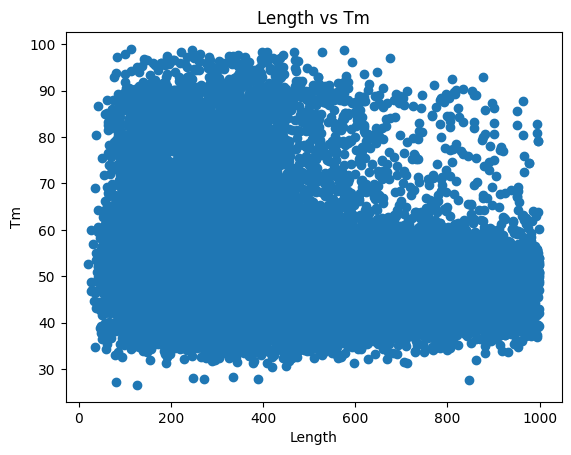

Pearson correlation: -0.1375494156978899
Pearson p-value: 1.1547068332303256e-126


In [1]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, PowerTransformer, RobustScaler
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, DataStructs
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.svm import SVR
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

#counts the number of times an amino acid occurs in the sequence
def count_amino_acid(seq, amino_acid):
    return seq.count(amino_acid)

df = pd.read_csv("full_promelt_seq.csv")
#remove rows with invalid amino acids
df = df[df["sequence"].str.count("X")==0]
df = df[df["sequence"].str.count("U")==0]
df = df[df["sequence"].str.count("Z")==0]
df = df[df["sequence"].str.count("B")==0]

#remove rows with very long sequences
df = df[df["Length"]<1000]

#this will use the string count function on all items in the sequence column (similar to the apply we covered before)
df["A"] = df["sequence"].str.count('A')
df["C"] = df["sequence"].str.count('C')
df["D"] = df["sequence"].str.count('D')
df["E"] = df["sequence"].str.count('E')
df["F"] = df["sequence"].str.count('F')
df["G"] = df["sequence"].str.count('G')
df["H"] = df["sequence"].str.count('H')
df["I"] = df["sequence"].str.count('I')
df["K"] = df["sequence"].str.count('K')
df["L"] = df["sequence"].str.count('L')
df["M"] = df["sequence"].str.count('M')
df["N"] = df["sequence"].str.count('N')
df["P"] = df["sequence"].str.count('P')
df["Q"] = df["sequence"].str.count('Q')
df["R"] = df["sequence"].str.count('R')
df["S"] = df["sequence"].str.count('S')
df["T"] = df["sequence"].str.count('T')
df["V"] = df["sequence"].str.count('V')
df["W"] = df["sequence"].str.count('W')
df["Y"] = df["sequence"].str.count('Y')

#we will also turn some of these features into categorical formats by thresholding for the examples below
df['stable'] = df["Tm"] > 50
df['very_long_protein'] = df["Length"] > 800


#split the training and test data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

#now let's look at the correlation between some of the features and solubility
#try changing the feature to see which is more correlated
#note that you want to limit this analysis to the training set so that the test set does not leak into your choices of features
plt.figure()
plt.scatter(train_df["Length"], train_df["Tm"])

# Add labels
plt.xlabel("Length")
plt.ylabel("Tm")
plt.title("Length vs Tm")

# Show plot
plt.show()

# Pearson
pearson_corr, pearson_p = pearsonr(train_df["Length"], train_df["Tm"])
print(f"Pearson correlation: {pearson_corr}")
print(f"Pearson p-value: {pearson_p}")

# One variable is categorical
If one variable is categorical, we can compare distributions for the other variable in each category. This can be done visually through a histogram and statistical tests for comparing distributions can be used to get a quantitative comparison

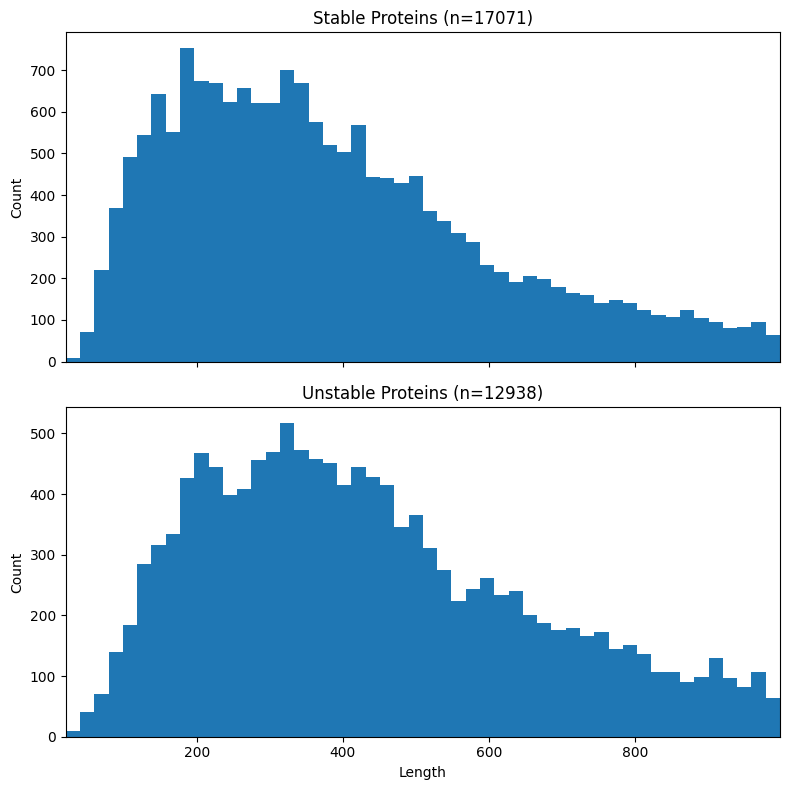

In [2]:
#let's look at the length distribution for stable and unstable proteins
soluble_df = train_df.loc[train_df["stable"]==1]
insoluble_df = train_df.loc[train_df["stable"]==0]

# Use numpy's automatic bin rule (or set a fixed number like bins=30)
bins = np.histogram_bin_edges(train_df["Length"], bins="auto")

#get the min and max values over both datsets
xmin, xmax = train_df["Length"].min(), train_df["Length"].max()

#creates a figure with 2 rows and 1 column
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

#note we can use plt for single graphs, but here we will use axs[i] where i is the subgraph we want to plot on
axs[0].hist(soluble_df["Length"], bins=bins)
axs[0].set_title(f"Stable Proteins (n={len(soluble_df)})")
axs[0].set_ylabel("Count")
axs[0].set_xlim(xmin, xmax)

axs[1].hist(insoluble_df["Length"], bins=bins)
axs[1].set_title(f"Unstable Proteins (n={len(insoluble_df)})")
axs[1].set_xlabel("Length")
axs[1].set_ylabel("Count")
axs[1].set_xlim(xmin, xmax)

plt.tight_layout()
plt.show()

# Both variables are categorical
If both variables are categorical we can use a chi-squared test to determine if there is a significant association.

In [3]:
from scipy.stats import chi2_contingency

#we will look at the association betweeen a protein being very short and it being stable

#first construct the table with counts
table = pd.crosstab(df["very_long_protein"], df["stable"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("p-value: "+ str(p))

#from all three of these analyses we can see that very long proteins are more likely to be unstable
#but the assocation between length and stability at lower lengths is weak or nonexistant

stable             False  True 
very_long_protein              
False              14852  20027
True                1314   1319
p-value: 2.943350826386985e-13


# Correlation between features
If features are not independent then including both in the model leads to redundant information. The same techniques described above to look at how features relate to the target to look at how features relate to each other. Length will be related to the counts of the individual amino acids so if we are including all amino acids as counts (not fractions) it is redundant to include length. If features show high correlation or association then it may be helpful to leave one out of the model.

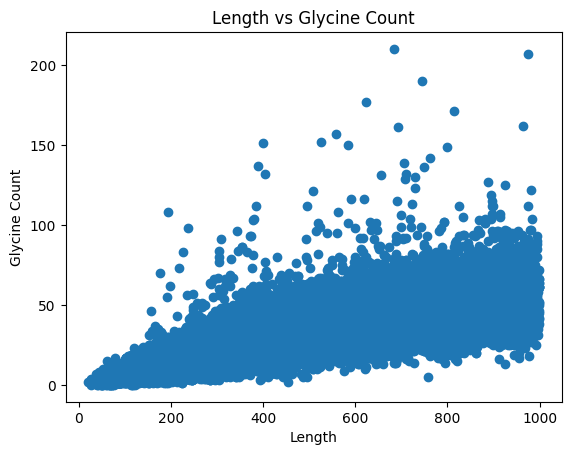

Pearson correlation: 0.7937214398768655
Pearson p-value: 0.0


In [4]:
# let's look at correlation between length and glycine count
plt.figure()
plt.scatter(train_df["Length"], train_df["G"])

# Add labels
plt.xlabel("Length")
plt.ylabel("Glycine Count")
plt.title("Length vs Glycine Count")

# Show plot
plt.show()

# Pearson
pearson_corr, pearson_p = pearsonr(train_df["Length"], train_df["G"])
print(f"Pearson correlation: {pearson_corr}")
print(f"Pearson p-value: {pearson_p}")

# Univariate Feature Selection - Regression
We can use Univariate Feature selection to automate our feature selection

In [5]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import r_regression

X_train = train_df[["A","C","D","E","F","G","H","I","K","L","M","N",\
                               "P","Q","R","S","T","V","W","Y"]]

#we need to specify the statistic used first, then k specifies the number of features we want to keep
#r_regression uses Pearson's correlation
selector = SelectKBest(r_regression, k=2)
train_new = selector.fit_transform(X_train, train_df["Tm"])

#let's look at what features it chose
selected_features = X_train.columns[selector.get_support()]
print(selected_features)

Index(['A', 'R'], dtype='str')


# Univariate Feature Selection - Classification

In [6]:
from sklearn.feature_selection import f_classif

#we need to specify the statistic used first, then k specifies the number of features we want to keep
#we need to use a classification statistic, everything else can staty the same
selector = SelectKBest(f_classif, k=2)
train_new = selector.fit_transform(X_train, train_df["stable"])

#let's look at what features it chose
selected_features = X_train.columns[selector.get_support()]
print(selected_features)


Index(['I', 'N'], dtype='str')


# Recursive feature elimination
Sometimes it is impractical to inspect every feature, especially if we possibly have feature interactions to look at. Recursive feature elimination can be used to remove features one at a time leaving only those that lead to a good model. Scikit-learn offers one method that let's you specify how many features to keep and another that determines that through comparison of cross validation with different numbers of features.

In [7]:
from sklearn.feature_selection import RFE, RFECV, SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.svm import SVR

#RFE requires a clasisifier that has either coefficients or an importance score, these include logistic regression or linear regression for coefficients
#and tree based methods for importance scores

#let's use a tree based method because it can look at interactions between features
rfr = RandomForestRegressor(n_estimators=10)

#first let's try RFE which let's you specify how many features are kept
#n_features_to_select determines how many features are kept and step how many features are removed at each run
rfe = RFE(
    estimator=rfr,
    n_features_to_select=2,
    step=1
)

X_selected = rfe.fit_transform(X_train, train_df["stable"])
selected_features = X_train.columns[rfe.support_]
# we can look at the feature ranking, 1 is a selected feature.
#for other values the larger the number the sooner it was eliminated
print("RFE ranking:")
print(rfe.ranking_)  

#set up our cross validation splits
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#make sure to choose a regression metric for regression and classification metric for classification
rfecv = RFECV(
    estimator=rfr,
    step=1,
    cv=cv,
    scoring="neg_mean_squared_error"
)

X_selected = rfecv.fit_transform(X_train, train_df["stable"])

print("Optimal number of features:", rfecv.n_features_)
print("RFECV ranking:")
print(rfecv.ranking_) #ranking works the same way as in the RFE example

#If we want to do this for a support vector model we can't ues coefficients/importance scores
#SequentialFeatureSelector let's us do this, we can run in the forward direction to add features
#or the reverse direction to remove features
svr_rbf = SVR(kernel="rbf") #let's use an SVR with a non-linear kernel so that interactions between features are used

#again with the SequentialFeatureSelector requires you to specify how many features you want
#this is slow so we will limit the dataset size
sfs = SequentialFeatureSelector(
    estimator=svr_rbf,
    n_features_to_select=15,
    direction="backward",
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

X_selected = sfs.fit_transform(X_train[1:1000], train_df["stable"][1:1000])


print("SFS selected features:")

selected_features = X_train.columns[sfs.get_support()]
print(selected_features)


RFE ranking:
[ 1 16 12  4 13  2 18  5  7  1 17  8  9  6 10  3 14 11 19 15]
Optimal number of features: 19
RFECV ranking:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1]
SFS selected features:
Index(['A', 'C', 'E', 'G', 'H', 'I', 'K', 'M', 'P', 'Q', 'R', 'S', 'T', 'V',
       'Y'],
      dtype='str')


# Linear Discriminant Analysis
Linear discriminant analysis can apply supervised dimensionality reduction for classification, where components are found that separate the classes. Let's compare it to PCA.

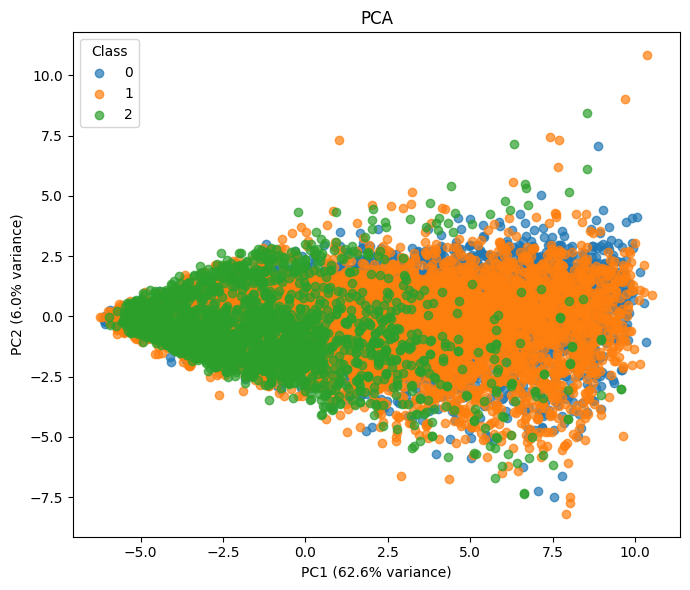

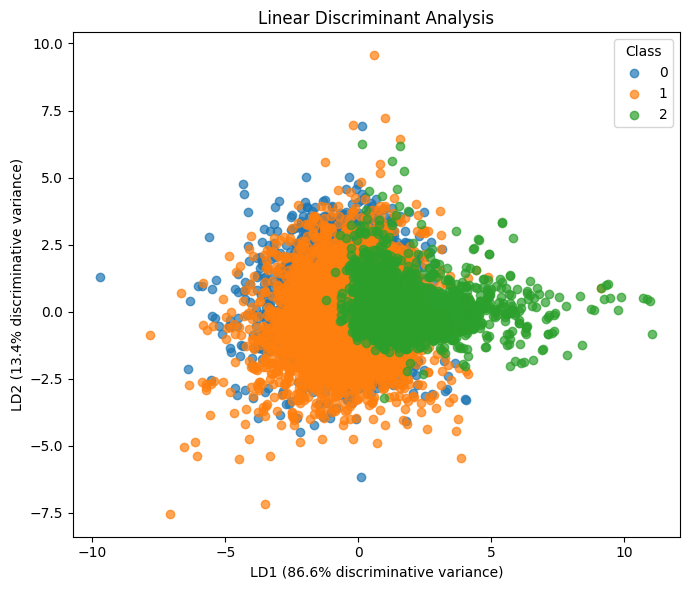

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

#first scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)


#LDA can have a maximum number of components of min(num features, num classes -1)
#so with binary classification, we can only have one component, this doesn't look good on a graph
#let's add make three possible classes: very stable (2), stable (1), and unstable (0)
train_df["stability_level"] = np.select(
    [
        train_df["Tm"] >= 70,
        train_df["Tm"] >= 50
    ],
    [
        2,
        1
    ],
    default=0
)

#apply and plot PCA colored by class
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))

for class_label in sorted(set(train_df["stability_level"])):
    mask = (train_df["stability_level"] == class_label)

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=str(class_label),
        alpha=0.7
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.title("PCA")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

#apply and plot LDA colored by class
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, train_df["stability_level"])

plt.figure(figsize=(7, 6))

for class_label in sorted(set(train_df["stability_level"])):
    mask = (train_df["stability_level"] == class_label)

    plt.scatter(
        X_lda[mask, 0],
        X_lda[mask, 1],
        label=str(class_label),
        alpha=0.7
    )

plt.xlabel(
    f"LD1 ({lda.explained_variance_ratio_[0]*100:.1f}% discriminative variance)"
)
plt.ylabel(
    f"LD2 ({lda.explained_variance_ratio_[1]*100:.1f}% discriminative variance)"
)

plt.title("Linear Discriminant Analysis")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

# Partial Least squares
Use partial least squares for supervised dimensionality reduction for regression

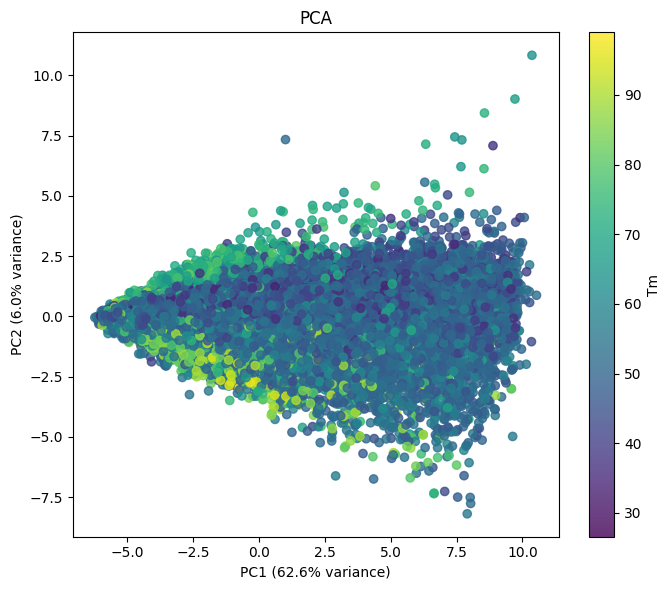

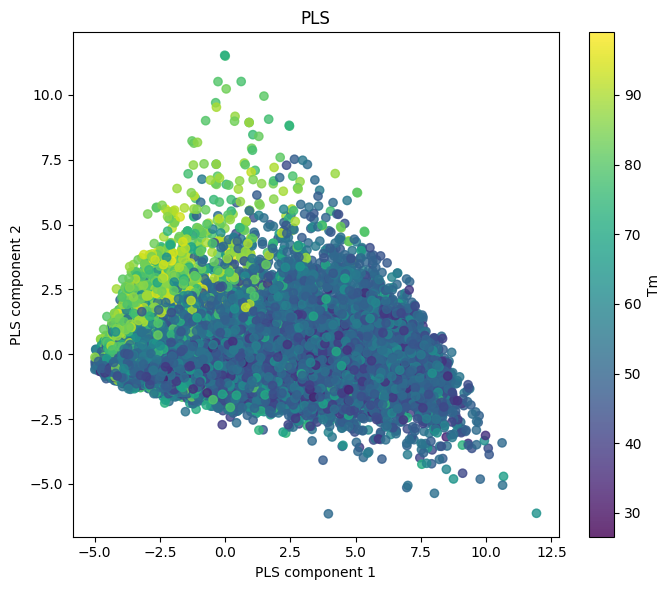

In [11]:
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=2)
X_pls = pls.fit_transform(X_scaled, train_df["Tm"])[0]

#plot PCA colored by value for comparison
plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=train_df["Tm"],
    alpha=0.8
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.title("PCA")
plt.colorbar(scatter, label="Tm")
plt.tight_layout()
plt.show()

#plot the PLS results
X_pls = pls.x_scores_

plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    X_pls[:, 0],
    X_pls[:, 1],
    c=train_df["Tm"],
    alpha=0.8
)

plt.xlabel("PLS component 1")
plt.ylabel("PLS component 2")

plt.title("PLS")
plt.colorbar(scatter, label="Tm")
plt.tight_layout()
plt.show()
